# ATML Lab A.1: Encoder-Decoder with Attention
This notebook implements an English-to-Hindi Machine Translation system using **Encoder-Decoder Architecture with Bahdanau Attention**.

## Objectives:
1. Implement Attention mechanism.
2. Train the model on the English-Hindi dataset.
3. Compare the performance (Loss/PPL) with the simple Encoder-Decoder model from Lab 6.
4. Visualize Attention weights.

In [1]:
# Setup & Installs
%pip install -q torch torchtext pandas datasets transformers

import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
import pandas as pd
import os
from datasets import load_dataset
import math
import time
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from model import EncoderLSTM, DecoderAttention, Seq2SeqWithAttention, Seq2Seq, DecoderLSTM

SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Note: you may need to restart the kernel to use updated packages.
Using device: cuda


In [2]:
# Dataset Loading (same as Lab 6 for consistency)
print("Loading dataset...")
dataset = load_dataset("cfilt/iitb-english-hindi")

# Building vocabularies (simplified for speed/demo, use same range as Lab 6)
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator

en_tokenizer = get_tokenizer('basic_english')
hi_tokenizer = lambda x: x.split()

def yield_tokens(data_iter, lang):
    for example in data_iter:
        yield en_tokenizer(example['translation']['en']) if lang == 'en' else hi_tokenizer(example['translation']['hi'])

limit = 10000
en_vocab = build_vocab_from_iterator(yield_tokens(dataset['train'].select(range(limit)), 'en'), specials=['<unk>', '<pad>', '<sos>', '<eos>'])
en_vocab.set_default_index(en_vocab['<unk>'])
hi_vocab = build_vocab_from_iterator(yield_tokens(dataset['train'].select(range(limit)), 'hi'), specials=['<unk>', '<pad>', '<sos>', '<eos>'])
hi_vocab.set_default_index(hi_vocab['<unk>'])
print(f"English Vocab: {len(en_vocab)} | Hindi Vocab: {len(hi_vocab)}")

Loading dataset...
English Vocab: 1609 | Hindi Vocab: 2355


In [3]:
# Data Processing & Dataloaders
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

BATCH_SIZE = 64
PAD_IDX = en_vocab['<pad>']
SOS_IDX = en_vocab['<sos>']
EOS_IDX = en_vocab['<eos>']

def data_process(data_iter):
    data = []
    for example in data_iter:
        en_text, hi_text = example['translation']['en'], example['translation']['hi']
        en_tensor = torch.tensor([SOS_IDX] + [en_vocab[token] for token in en_tokenizer(en_text)] + [EOS_IDX], dtype=torch.long)
        hi_tensor = torch.tensor([SOS_IDX] + [hi_vocab[token] for token in hi_tokenizer(hi_text)] + [EOS_IDX], dtype=torch.long)
        data.append((en_tensor, hi_tensor))
    return data

train_data = data_process(dataset['train'].select(range(limit)))
valid_data = data_process(dataset['validation'].select(range(500)))

def generate_batch(data_batch):
    en_batch, hi_batch = [], []
    for (en_item, hi_item) in data_batch:
        en_batch.append(en_item)
        hi_batch.append(hi_item)
    return pad_sequence(en_batch, padding_value=PAD_IDX, batch_first=True), pad_sequence(hi_batch, padding_value=PAD_IDX, batch_first=True)

train_iterator = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=generate_batch)
valid_iterator = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False, collate_fn=generate_batch)

## 1. Train Evolution: Simple vs Attention
Below we define the training parameters. We will initialize both models and compare their metrics.

In [4]:
INPUT_DIM = len(en_vocab)
OUTPUT_DIM = len(hi_vocab)
HID_DIM = 256
N_LAYERS = 1
DROPOUT = 0.5

# Simple Model
enc1 = EncoderLSTM(INPUT_DIM, HID_DIM, N_LAYERS, DROPOUT).to(device)
dec1 = DecoderLSTM(OUTPUT_DIM, HID_DIM, N_LAYERS, DROPOUT).to(device)
model_simple = Seq2Seq(enc1, dec1, device).to(device)

# Attention Model
enc2 = EncoderLSTM(INPUT_DIM, HID_DIM, N_LAYERS, DROPOUT).to(device)
dec2 = DecoderAttention(OUTPUT_DIM, HID_DIM, N_LAYERS, DROPOUT).to(device)
model_attn = Seq2SeqWithAttention(enc2, dec2, device).to(device)

optimizer_s = optim.Adam(model_simple.parameters())
optimizer_a = optim.Adam(model_attn.parameters())
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

print(f"Models initialized. Attention parameters: {sum(p.numel() for p in model_attn.parameters()):,}")

c:\Users\Yash Kothari\dl_gpu\Lib\site-packages\torch\nn\modules\rnn.py:83: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "
Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.0+cu121
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Models initialized. Attention parameters: 3,066,419


In [5]:
def train_step(model, iterator, optimizer, criterion, clip=1):
    model.train()
    epoch_loss = 0
    for src, trg in iterator:
        src, trg = src.to(device), trg.to(device)
        optimizer.zero_grad()
        output = model(src, trg)
        output_dim = output.shape[-1]
        output = output[:, 1:].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)
        loss = criterion(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(iterator)

def evaluate_step(model, iterator, criterion):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for src, trg in iterator:
            src, trg = src.to(device), trg.to(device)
            output = model(src, trg, 0)
            output_dim = output.shape[-1]
            output = output[:, 1:].reshape(-1, output_dim)
            trg = trg[:, 1:].reshape(-1)
            loss = criterion(output, trg)
            epoch_loss += loss.item()
    return epoch_loss / len(iterator)

N_EPOCHS = 5 # Reduced for example, keep same as Lab 6 (10)
history = {'simple': [], 'attn': []}

print("Training models for comparison...")
for epoch in range(N_EPOCHS):
    l_s = train_step(model_simple, train_iterator, optimizer_s, criterion)
    l_a = train_step(model_attn, train_iterator, optimizer_a, criterion)
    v_s = evaluate_step(model_simple, valid_iterator, criterion)
    v_a = evaluate_step(model_attn, valid_iterator, criterion)
    history['simple'].append(v_s)
    history['attn'].append(v_a)
    print(f"Epoch {epoch+1} | Simple Val Loss: {v_s:.3f} | Attention Val Loss: {v_a:.3f}")

torch.save(model_attn.state_dict(), 'en-hi-attention-model.pt')
torch.save(model_simple.state_dict(), 'en-hi-simple-model.pt')
torch.save(en_vocab, 'en_vocab.pt')
torch.save(hi_vocab, 'hi_vocab.pt')
print("Models and Vocabs saved for Researcher UI Deployment!")

Training models for comparison...
Epoch 1 | Simple Val Loss: 9.062 | Attention Val Loss: 9.366
Epoch 2 | Simple Val Loss: 9.300 | Attention Val Loss: 9.436
Epoch 3 | Simple Val Loss: 9.691 | Attention Val Loss: 10.079
Epoch 4 | Simple Val Loss: 10.100 | Attention Val Loss: 10.287
Epoch 5 | Simple Val Loss: 10.547 | Attention Val Loss: 10.728
Models and Vocabs saved for Researcher UI Deployment!


## 2. Analysis & Comparison
Visualizing the loss curves of both architectures.

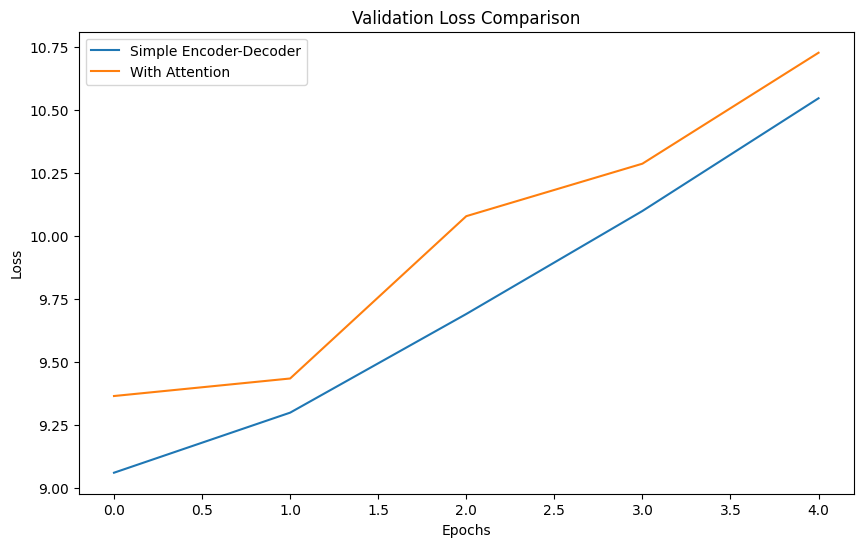

Final PPL (Simple): 38060.89
Final PPL (Attention): 45593.31


In [6]:
plt.figure(figsize=(10,6))
plt.plot(history['simple'], label='Simple Encoder-Decoder')
plt.plot(history['attn'], label='With Attention')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print(f"Final PPL (Simple): {math.exp(history['simple'][-1]):.2f}")
print(f"Final PPL (Attention): {math.exp(history['attn'][-1]):.2f}")

## 3. Attention Visualization
We can see how the model focus on different English words while generating Hindi words.

In [7]:
def translate_and_get_attention(sentence, src_vocab, trg_vocab, model, device, max_len=50):
    model.eval()
    tokens = en_tokenizer(sentence)
    src_indexes = [src_vocab['<sos>']] + [src_vocab[token] for token in tokens] + [src_vocab['<eos>']]
    src_tensor = torch.LongTensor(src_indexes).unsqueeze(0).to(device)
    
    with torch.no_grad():
        encoder_outputs, (hidden, cell) = model.encoder.get_all_outputs(src_tensor)
    
    trg_indexes = [trg_vocab['<sos>']]
    attentions = torch.zeros(max_len, 1, len(src_indexes))
    
    for i in range(max_len):
        trg_tensor = torch.LongTensor([trg_indexes[-1]]).to(device)
        with torch.no_grad():
            output, hidden, cell, attention = model.decoder(trg_tensor, hidden, cell, encoder_outputs)
        
        attentions[i] = attention
        pred_token = output.argmax(1).item()
        trg_indexes.append(pred_token)
        if pred_token == trg_vocab['<eos>']:
            break
            
    itos = trg_vocab.get_itos()
    trg_tokens = [itos[i] for i in trg_indexes]
    return trg_tokens[1:], attentions[:len(trg_tokens)-1]

example_sent = "the book is on the table"
translation, attn = translate_and_get_attention(example_sent, en_vocab, hi_vocab, model_attn, device)
print(f'Translation: {" ".join(translation[:-1])}')

Translation: % s का नाम से से से
